# Fine-tune the pretrained CHGNet for better accuracy


In [28]:
try:
    from chgnet.model import CHGNet
except ImportError:
    # install CHGNet (only needed on Google Colab or if you didn't install CHGNet yet)
    !pip install chgnet

In [2]:
import numpy as np
from pymatgen.core import Structure

# If the above line fails in Google Colab due to numpy version issue,
# please restart the runtime, and the problem will be solved

## 0. Parse DFT outputs to CHGNet readable formats


CHGNet is interfaced to [Pymatgen](https://pymatgen.org/), the training samples (normally coming from different DFTs like VASP),
need to be converted to [pymatgen.core.structure](https://pymatgen.org/pymatgen.core.html#module-pymatgen.core.structure).

To convert VASP calculation to pymatgen structures and CHGNet labels, you can use the following [code](https://github.com/CederGroupHub/chgnet/blob/main/chgnet/utils/vasp_utils.py):


In [3]:
!unzip CsSnI3_test_data_1000_points.zip

Archive:  CsSnI3_test_data_1000_points.zip
   creating: CsSnI3_test_data_1000_points/
   creating: CsSnI3_test_data_1000_points/001-16i-24cssni3_-.35962997/
  inflating: __MACOSX/CsSnI3_test_data_1000_points/._001-16i-24cssni3_-.35962997  
   creating: CsSnI3_test_data_1000_points/001-8sn16i4cs8i-24cssni3_-.43123483/
  inflating: __MACOSX/CsSnI3_test_data_1000_points/._001-8sn16i4cs8i-24cssni3_-.43123483  
  inflating: CsSnI3_test_data_1000_points/.DS_Store  
  inflating: __MACOSX/CsSnI3_test_data_1000_points/._.DS_Store  
   creating: CsSnI3_test_data_1000_points/001-8sn16i8cs4i-24cssni3_-.43270813/
  inflating: __MACOSX/CsSnI3_test_data_1000_points/._001-8sn16i8cs4i-24cssni3_-.43270813  
   creating: CsSnI3_test_data_1000_points/001-24cssni3-pos2_-.33373358/
  inflating: __MACOSX/CsSnI3_test_data_1000_points/._001-24cssni3-pos2_-.33373358  
   creating: CsSnI3_test_data_1000_points/001-6sn16i-24cssni3_-.39102195/
  inflating: __MACOSX/CsSnI3_test_data_1000_points/._001-6sn16i-24cssni

In [4]:
from chgnet.utils import parse_vasp_dir


# dataset_dict = parse_vasp_dir(
#     base_dir="/content/CsSnI3_test_data_1000_points/001-16i-24cssni3_-.35962997",
#     save_path="/content/CsSnI3_test_data_1000_points/001-16i-24cssni3_-.35962997/chgnet_dataset.json"
# )

# print(list(dataset_dict))

The parsed python dictionary includes information for CHGNet inputs (structures), and CHGNet prediction labels (energy, force, stress ,magmom).

we can save the parsed structures and labels to disk, so that they can be easily reloaded during multiple rounds of training.

The json file can be saved by providing the save_path


The Pymatgen structures can be saved separately if you're interested to take a look into each structure.

Below are the example codes to save the structures in either json, pickle, cif, or CHGNet graph.

For super-large training dataset, like MPtrj dataset, we recommend [converting them to CHGNet graphs](https://github.com/CederGroupHub/chgnet/blob/main/examples/make_graphs.py). This will save significant memory and graph computing time.


In [18]:
# # Structure to json
# from chgnet.utils import write_json

# dict_to_json = [struct.as_dict() for struct in dataset_dict["structure"]]
# write_json(dict_to_json, "CHGNet_structures.json")


# # Structure to pickle
# import pickle

# with open("CHGNet_structures.p", "wb") as f:
#     pickle.dump(dataset_dict, f)


# # Structure to cif
# for idx, struct in enumerate(dataset_dict["structure"]):
#     struct.to(filename=f"{idx}.cif")


# # Structure to CHGNet graph
# from chgnet.graph import CrystalGraphConverter

# converter = CrystalGraphConverter()
# for idx, struct in enumerate(dataset_dict["structure"]):
#     graph = converter(struct)
#     graph.save(fname=f"{idx}.pt")

For other types of DFT calculations, please refer to their interfaces
in [pymatgen.io](https://pymatgen.org/pymatgen.io.html#module-pymatgen.io).

see: [Quantum Espresso](https://pymatgen.org/pymatgen.io.html#module-pymatgen.io.pwscf)

see: [CP2K](https://pymatgen.org/pymatgen.io.cp2k.html#module-pymatgen.io.cp2k)

see: [Gaussian](https://pymatgen.org/pymatgen.io.html#module-pymatgen.io.gaussian)


## 1. Prepare Training Data


If you have parsed your VASP labels from step 0, you can reload the saved json file.


In [19]:
# from chgnet.utils import read_json

# dataset_dict = read_json("/content/CsSnI3_test_data_1000_points/001-16i-24cssni3_-.35962997/chgnet_dataset.json")
# structures = [Structure.from_dict(struct) for struct in dataset_dict["structure"]]
# energies = dataset_dict["energy_per_atom"]
# forces = dataset_dict["force"]
# stresses = dataset_dict.get("stress") or None
# magmoms = dataset_dict.get("magmom") or None

If you don't have any DFT calculations now, we can create a dummy fine-tuning dataset by using CHGNet prediction with some random noise.


In [20]:
# from chgnet.model import CHGNet
# from pymatgen.core import Structure

# try:
#     from chgnet import ROOT

#     lmo = Structure.from_file(f"{ROOT}/examples/mp-18767-LiMnO2.cif")
# except Exception:
#     from urllib.request import urlopen

#     url = "https://raw.githubusercontent.com/CederGroupHub/chgnet/main/examples/mp-18767-LiMnO2.cif"
#     cif = urlopen(url).read().decode("utf-8")
#     lmo = Structure.from_str(cif, fmt="cif")

# structures, energies_per_atom, forces, stresses, magmoms = [], [], [], [], []
# chgnet = CHGNet.load()
# for _ in range(100):
#     structure = lmo.copy()
#     # stretch the cell by a small amount
#     structure.apply_strain(np.random.uniform(-0.1, 0.1, size=3))
#     # perturb all atom positions by a small amount
#     structure.perturb(0.1)

#     pred = chgnet.predict_structure(structure)

#     structures.append(structure)
#     energies_per_atom.append(pred["e"] + np.random.uniform(-0.1, 0.1, size=1))
#     forces.append(pred["f"] + np.random.uniform(-0.01, 0.01, size=pred["f"].shape))
#     stresses.append(
#         pred["s"] * -10 + np.random.uniform(-0.05, 0.05, size=pred["s"].shape)
#     )
#     magmoms.append(pred["m"] + np.random.uniform(-0.03, 0.03, size=pred["m"].shape))

Note that the stress output from CHGNet is in unit of GPa, here the -10 unit conversion
modifies it to be kbar in VASP raw unit.
If you're using stress labels from VASP, you don't need to do any unit conversions
StructureData dataset class takes in VASP units.


## 2. Define DataSet


In [5]:
from pathlib import Path
from chgnet.utils import parse_vasp_dir

root = Path("/content/CsSnI3_test_data_1000_points")

calc_dirs = sorted([d for d in root.iterdir() if d.is_dir()])

print(f"Found {len(calc_dirs)} calculations.")

structures = []
energies = []
forces = []
stresses = []
magmoms = []

for i, calc_dir in enumerate(calc_dirs):

    # Skip the third folder
    if i == 2:
        print(f"Skipping {calc_dir.name}")
        continue

    data = parse_vasp_dir(str(calc_dir))

    # Each folder may contain one or more ionic steps,
    # so extend instead of append.
    structures.extend(data["structure"])
    energies.extend(data["energy_per_atom"])
    forces.extend(data["force"])
    stresses.extend(data["stress"])
    magmoms.extend(data["magmom"])

print(f"Loaded {len(structures)} structures.")

Found 14 calculations.
Skipping 001-24cssni3_-.33404215
Loaded 1135 structures.


In [6]:
from chgnet.data.dataset import StructureData, get_train_val_test_loader

In [7]:
print(len(structures))
print(len(energies))
print(len(forces))
print(len(stresses))
print(len(magmoms))

1135
1135
1135
1135
0


In [8]:
from chgnet.data.dataset import StructureData

if len(magmoms) == 0:
    magmoms = None

dataset = StructureData(
    structures=structures,
    energies=energies,
    forces=forces,
    stresses=stresses,
    magmoms=magmoms,
)

StructureData imported 1,135 structures


Alternatively, the dataset can be directly created from VASP calculation dir.
This function essentially parse the VASP directory first, save the labels to json file, and create the StructureData class


In [25]:
# dataset = StructureData.from_vasp(
#     file_root="./my_vasp_calc_dir", save_path="./my_vasp_calc_dir/chgnet_dataset.json"
# )

The training set is used to optimize the CHGNet through gradient descent, the validation set is used to see validation error at the end of each epoch, and the test set is used to see the final test error at the end of training. The test set can be optional.

The `batch_size` is defined to be 8 for small GPU-memory. If > 10 GB memory is available, we highly recommend to increase `batch_size` for better speed.

If you have very large numbers (>100K) of structures (which is typical for AIMD), putting them all in a python list can quickly run into memory issues. In this case we highly recommend you to pre-convert all the structures into graphs and save them as shown in `examples/make_graphs.py`. Then directly train CHGNet by loading the graphs from disk instead of memory using the `GraphData` class defined in `data/dataset.py`.


## 3. Define model and trainer


In [9]:
from chgnet.model import CHGNet
from chgnet.trainer import Trainer

# Load pretrained CHGNet
chgnet = CHGNet.load()

CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cuda


It's optional to freeze the weights inside some layers. This is a common technique to retain the learned knowledge during fine-tuning in large pretrained neural networks. You can choose the layers you want to freeze.


In [10]:
# Optionally fix the weights of some layers
for layer in [
    chgnet.atom_embedding,
    chgnet.bond_embedding,
    chgnet.angle_embedding,
    chgnet.bond_basis_expansion,
    chgnet.angle_basis_expansion,
    chgnet.atom_conv_layers[:-1],
    chgnet.bond_conv_layers,
    chgnet.angle_layers,
]:
    for param in layer.parameters():
        param.requires_grad = False

In [11]:
# Define Trainer
trainer = Trainer(
    model=chgnet,
    targets="efs", #efsm
    optimizer="Adam",
    scheduler="CosLR",
    criterion="MSE",
    epochs=2,
    learning_rate=1e-2,
    use_device="cuda",
    print_freq=6,
)

In [12]:
from chgnet.data.dataset import get_train_val_test_loader

train_loader, val_loader, test_loader = get_train_val_test_loader(
    dataset,
    batch_size=8,
    train_ratio=0.8,  # Example: 80% for training
    val_ratio=0.1,    # Example: 10% for validation
    # The remaining 10% will be used for the test set automatically.
    # Note: The sum of train_ratio and val_ratio should be less than 1.0
    # You can adjust these ratios as needed for your dataset.
    # For the current dataset size (1135 structures), ensure these ratios result in non-empty splits.
)

## 4. Start training


In [13]:
# print("dataset" in globals())
# print("train_loader" in globals())
# print("val_loader" in globals())
# print("test_loader" in globals())

In [14]:
# from google.colab import drive
# drive.mount('/content/drive')

In [17]:
# from chgnet.data.dataset import get_train_val_test_loader

# train_loader, val_loader, test_loader = get_train_val_test_loader(
#     dataset,
#     batch_size=8,
#     train_ratio=0.9,
#     val_ratio=0.05,
#)

In [15]:
import torch
print(torch.cuda.is_available())

True


In [16]:
!nvidia-smi

Mon Jun 15 15:02:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P0             26W /   70W |     107MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [18]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [19]:
trainer.train(train_loader, val_loader, test_loader)

Begin Training: using cuda device
training targets: efs
Epoch: [0][1/114] | Time (1.772)(0.109) | Loss 9.1798(9.1798) | MAE e 3.029(3.029)  f 0.038(0.038)  s 0.049(0.049)  
Epoch: [0][6/114] | Time (0.539)(0.086) | Loss 3.2072(6.1485) | MAE e 1.772(2.437)  f 0.179(0.098)  s 0.203(0.092)  
Epoch: [0][12/114] | Time (0.409)(0.082) | Loss 0.6369(3.4589) | MAE e 0.732(1.568)  f 0.218(0.149)  s 0.191(0.161)  
Epoch: [0][18/114] | Time (0.368)(0.081) | Loss 0.0402(2.4489) | MAE e 0.134(1.233)  f 0.109(0.148)  s 0.070(0.135)  
Epoch: [0][24/114] | Time (0.378)(0.101) | Loss 0.1688(1.8602) | MAE e 0.395(0.987)  f 0.074(0.132)  s 0.063(0.114)  
Epoch: [0][30/114] | Time (0.369)(0.101) | Loss 0.0572(1.5097) | MAE e 0.164(0.849)  f 0.082(0.121)  s 0.034(0.099)  
Epoch: [0][36/114] | Time (0.355)(0.098) | Loss 0.0403(1.2614) | MAE e 0.178(0.723)  f 0.056(0.111)  s 0.040(0.087)  
Epoch: [0][42/114] | Time (0.345)(0.096) | Loss 0.0143(1.0864) | MAE e 0.098(0.643)  f 0.046(0.103)  s 0.032(0.080)  
Ep

After training, the trained model can be found in the directory of today's date. Or it can be accessed by:


In [20]:
model = trainer.model
best_model = trainer.best_model  # best model based on validation energy MAE

In [21]:
from chgnet.utils import parse_vasp_dir

test_data = parse_vasp_dir(
    "/content/CsSnI3_test_data_1000_points/001-24cssni3_-.33404215"
)

In [22]:
test_data["structure"]
test_data["energy_per_atom"]
test_data["force"]
test_data["stress"]

[array([[-1.59978093e+00, -1.39999875e+00,  1.18200000e-04],
        [-1.39999872e+00, -3.45990788e+00,  5.24320000e-04],
        [ 1.18190000e-04,  5.24370000e-04, -2.23813832e+00]]),
 array([[-1.37220220e+00, -1.07306412e+00,  1.15650000e-04],
        [-1.07306416e+00, -2.93330596e+00,  5.29230000e-04],
        [ 1.15730000e-04,  5.29280000e-04, -2.00181948e+00]]),
 array([[-4.7045204e-01,  1.7990942e-01,  1.0858000e-04],
        [ 1.7990931e-01, -9.3620459e-01,  4.9759000e-04],
        [ 1.0857000e-04,  4.9760000e-04, -2.7639336e-01]]),
 array([[-3.2873256e-01,  3.7035916e-01,  1.0683000e-04],
        [ 3.7035914e-01, -6.3089338e-01,  4.9401000e-04],
        [ 1.0683000e-04,  4.9397000e-04,  6.7268000e-02]]),
 array([[-3.5927008e-01,  3.1790837e-01,  1.0702000e-04],
        [ 3.1790828e-01, -7.0575135e-01,  4.9379000e-04],
        [ 1.0704000e-04,  4.9379000e-04, -1.0749040e-02]]),
 array([[-2.8069653e-01,  4.4891350e-01,  1.0327000e-04],
        [ 4.4891347e-01, -4.7518649e-01,  5.

In [23]:
best_model = trainer.best_model

In [24]:
predicted_energy = []
predicted_force = []

for structure in test_data["structure"]:

    pred = best_model.predict_structure(structure)

    predicted_energy.append(pred["e"])
    predicted_force.append(pred["f"])

In [25]:
dft_energy = test_data["energy_per_atom"]

In [26]:
print(test_data["uncorrected_total_energy"][:10])
print(test_data["energy_per_atom"][:10])

[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0]
[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0]


In [27]:
dft_energy

[-0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0]

In [29]:
import numpy as np

energy_error = np.array(predicted_energy) - np.array(dft_energy)

mae = np.mean(np.abs(energy_error))

print("Energy MAE =", mae, "eV/atom")

Energy MAE = 0.00665629655122757 eV/atom


In [30]:
pred_force = np.concatenate(
    [f.reshape(-1, 3) for f in predicted_force],
    axis=0,
)

dft_force = np.concatenate(
    [f.reshape(-1, 3) for f in test_data["force"]],
    axis=0,
)

force_mae = np.mean(np.abs(pred_force - dft_force))

print("Force MAE =", force_mae, "eV/Å")

Force MAE = 0.038563521312850256 eV/Å


In [31]:
predicted_stress = []

for structure in test_data["structure"]:
    pred = best_model.predict_structure(structure)
    predicted_stress.append(pred["s"])

In [32]:
test_data["stress"]

[array([[-1.59978093e+00, -1.39999875e+00,  1.18200000e-04],
        [-1.39999872e+00, -3.45990788e+00,  5.24320000e-04],
        [ 1.18190000e-04,  5.24370000e-04, -2.23813832e+00]]),
 array([[-1.37220220e+00, -1.07306412e+00,  1.15650000e-04],
        [-1.07306416e+00, -2.93330596e+00,  5.29230000e-04],
        [ 1.15730000e-04,  5.29280000e-04, -2.00181948e+00]]),
 array([[-4.7045204e-01,  1.7990942e-01,  1.0858000e-04],
        [ 1.7990931e-01, -9.3620459e-01,  4.9759000e-04],
        [ 1.0857000e-04,  4.9760000e-04, -2.7639336e-01]]),
 array([[-3.2873256e-01,  3.7035916e-01,  1.0683000e-04],
        [ 3.7035914e-01, -6.3089338e-01,  4.9401000e-04],
        [ 1.0683000e-04,  4.9397000e-04,  6.7268000e-02]]),
 array([[-3.5927008e-01,  3.1790837e-01,  1.0702000e-04],
        [ 3.1790828e-01, -7.0575135e-01,  4.9379000e-04],
        [ 1.0704000e-04,  4.9379000e-04, -1.0749040e-02]]),
 array([[-2.8069653e-01,  4.4891350e-01,  1.0327000e-04],
        [ 4.4891347e-01, -4.7518649e-01,  5.

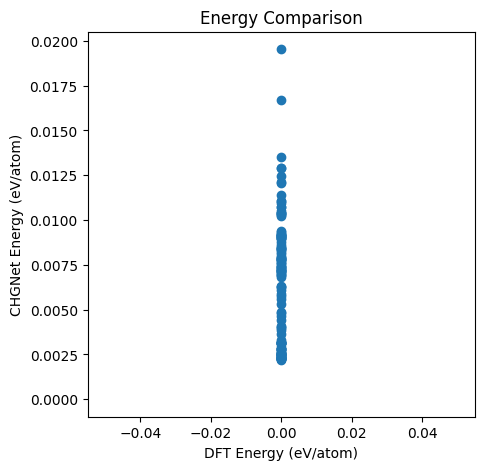

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.scatter(dft_energy, predicted_energy)

xmin = min(dft_energy)
xmax = max(dft_energy)

plt.plot([xmin, xmax], [xmin, xmax], "--")

plt.xlabel("DFT Energy (eV/atom)")
plt.ylabel("CHGNet Energy (eV/atom)")
plt.title("Energy Comparison")

plt.show()

In [34]:
print("DFT Energy samples:", dft_energy[:10])
print("Predicted Energy samples:", predicted_energy[:10])

DFT Energy samples: [-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0]
Predicted Energy samples: [array(0.01953554, dtype=float32), array(0.01670218, dtype=float32), array(0.01137352, dtype=float32), array(0.01096582, dtype=float32), array(0.01107097, dtype=float32), array(0.01074743, dtype=float32), array(0.01035118, dtype=float32), array(0.01028872, dtype=float32), array(0.01022816, dtype=float32), array(0.01072192, dtype=float32)]


## Extras 1: GGA / GGA+U compatibility


### Q: Why and when do you care about this?

**When**: If you want to fine-tune the pretrained CHGNet with your own GGA+U VASP calculations, and you want to keep your VASP energy compatible to the pretrained dataset. In case your dataset is so large that the pretrained knowledge does not matter to you, you can ignore this.

**Why**: CHGNet is trained on both GGA and GGA+U calculations from Materials Project. And there has been developed methods in solving the compatibility between GGA and GGA+U calculations which makes the energies universally applicable for cross-chemistry comparison and phase-diagram constructions. Please refer to:

https://journals.aps.org/prb/abstract/10.1103/PhysRevB.84.045115

Below we show an example to apply the compatibility.


In [ ]:
# Imagine this is the VASP raw energy
vasp_raw_energy = -58.97

print(f"The raw total energy from VASP of LMO is: {vasp_raw_energy} eV")

You can look for the energy correction applied to each element in :

https://github.com/materialsproject/pymatgen/blob/v2023.2.28/pymatgen/entries/MP2020Compatibility.yaml

Here LiMnO2 applies to both Mn in transition metal oxides correction and oxide correction.


To demystify `MaterialsProject2020Compatibility`, basically all that's happening is:


In [ ]:
Mn_correction_in_TMO = -1.668
oxide_correction = -0.687
_, num_Mn, num_O = lmo.composition.values()


corrected_energy = (
    vasp_raw_energy + num_Mn * Mn_correction_in_TMO + num_O * oxide_correction
)
print(f"The corrected total energy after MP2020 = {corrected_energy:.4} eV")

You can also apply the `MaterialsProject2020Compatibility` through pymatgen


In [ ]:
from pymatgen.entries.compatibility import MaterialsProject2020Compatibility
from pymatgen.entries.computed_entries import ComputedStructureEntry

params = {"hubbards": {"Mn": 3.9, "O": 0, "Li": 0}, "run_type": "GGA+U"}

cse = ComputedStructureEntry(lmo, vasp_raw_energy, parameters=params)

MaterialsProject2020Compatibility(check_potcar=False).process_entries(cse)
print(
    f"The total energy of LMO after MP2020Compatibility correction = {cse.energy:.4} eV"
)

Now use this corrected energy as labels to tune CHGNet, you're good to go!


## Extras 2: AtomRef


### Q: Why and when do you care about this?

**When**: When you fine tune CHGNet to DFT labels that are incompatible with Materials Project, like r2SCAN functional, or other DFTs like Gaussian or QE. The large shifts in elemental energy is not of our interest and should be reconciled. For example, Li has -0.95 eV/atom in GGA (https://next-gen.materialsproject.org/materials/mp-135/tasks/mp-990455) and -1.17 eV/atom in R2SCAN (https://next-gen.materialsproject.org/materials/mp-135/tasks/mp-1943895)

**Why**: The GNN learns the interaction between the atoms and the composition model (AtomRef) in CHGNet is used to normalize the elemental energy contribution, similar to a formation-energy-like calculation. During fine-tuning, we want to keep the most of knowledge unchanged in the GNN and allow the AtomRef to shift for the elemental energy change. So that the finetuning on the graph layers can be focused on energy contribution from atom-atom interaction instead of meaningless atom reference energies.

Below I will show an example to fit the AtomRef layer:


### A quick and easy way to turn on training of AtomRef in the trainer (this is by default off):


In [ ]:
trainer.train(train_loader, val_loader, test_loader, train_composition_model=True)

### The more regorous way is to solve for the per-atom contribution by linear regression in your fine-tuning dataset


In [ ]:
print("The pretrained Atom_Ref (per atom reference energy):")
for param in chgnet.composition_model.parameters():
    print(param)

In [ ]:
# A list of structures / graphs
structures = [
    lmo,
    Structure(
        species=["Li", "Mn", "Mn", "O", "O", "O"],
        lattice=np.random.rand(3, 3),
        coords=np.random.rand(6, 3),
    ),
    Structure(
        species=["Li", "Li", "Mn", "O", "O", "O"],
        lattice=np.random.rand(3, 3),
        coords=np.random.rand(6, 3),
    ),
    Structure(
        species=["Li", "Mn", "Mn", "O", "O", "O", "O"],
        lattice=np.random.rand(3, 3),
        coords=np.random.rand(7, 3),
    ),
]

# A list of energy_per_atom values (random values here)
energies_per_atom = [5.5, 6, 4.8, 5.6]

In [ ]:
from chgnet.model.composition_model import AtomRef

print("We initialize another identical AtomRef layers")
new_atom_ref = AtomRef(is_intensive=True)
new_atom_ref.initialize_from_MPtrj()
for param in new_atom_ref.parameters():
    print(param[:, :3])

In [ ]:
# Solve linear regression to find the per atom contribution in your fine-tuning dataset

new_atom_ref.fit(structures, energies_per_atom)
print("After refitting, the AtomRef looks like:")
for param in new_atom_ref.parameters():
    print(param)